In [5]:
from econml.orf import DMLOrthoForest, DROrthoForest
from econml.dml import CausalForestDML
from econml.sklearn_extensions.linear_model import WeightedLassoCVWrapper, WeightedLasso
from sklearn.model_selection import train_test_split

# Helper imports
import numpy as np
from itertools import product
from sklearn.linear_model import Lasso, LogisticRegression
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from scipy.special import expit 
import os
import pandas as pd
import urllib.request
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor
)

okabe_ito = {
    "orange":    "#E69F00",
    "sky_blue":  "#56B4E9",
    "green":     "#009E73",
    "yellow":    "#F0E442",
    "blue":      "#0072B2",
    "vermilion": "#D55E00",
    "pink":      "#CC79A7",
    "black":     "#000000",
}

oi_colors = list(okabe_ito.values())

%matplotlib inline

In [6]:
# We are going to load the data from the EconML site:

#oj_data = pd.read_csv("https://raw.githubusercontent.com/py-why/EconML/refs/heads/data/datasets/OrangeJuice/oj_large.csv")
oj_data = pd.read_csv("/home/georgehagstrom/work/Teaching/DATA622Spring2026/website/assignments/labs/labData/oj_large.csv")
oj_data.head()

,Unnamed: 0,store,brand,week,logmove,feat,price,AGE60,EDUC,ETHNIC,INCOME,HHLARGE,WORKWOM,HVAL150,SSTRDIST,SSTRVOL,CPDIST5,CPWVOL5
0,0,2,tropicana,40,9.018695,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
1,1,2,tropicana,46,8.723231,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
2,2,2,tropicana,47,8.253228,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
3,3,2,tropicana,48,8.987197,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927
4,4,2,tropicana,50,9.093357,0,3.87,0.232865,0.248935,0.11428,10.553205,0.103953,0.303585,0.463887,2.110122,1.142857,1.92728,0.376927


In [7]:
Y = oj_data["logmove"].values
T = oj_data["feat"].values

scaler = StandardScaler()

W1 = scaler.fit_transform(oj_data[ 
    [c for c in oj_data.columns if c not in ['logmove','brand','week','store','feat']]].values) 


W2 = pd.get_dummies(oj_data['brand'],drop_first= True)

W = np.concatenate([W1,W2],axis=1)

X = oj_data[['INCOME']].values

In [8]:
oj_data['logmove'].mean()

np.float64(9.167863993162849)

In [9]:
oj_data['feat'].mean()

np.float64(0.23726120150620097)

In [21]:
n, n_w = W.shape

income_min, income_max = X.min(), X.max()



def true_cate(X):
    x = (X-income_min)/(income_max-income_min)
    return 0.1 + 0.3*np.sin(np.pi*x)



TE_true = true_cate(X).ravel()


rng = np.random.default_rng(121111)

support_size = 5

support_idx = rng.choice(n_w,size=support_size,replace=False)


gamma = rng.uniform(-0.5,0.5,size=support_size)

propensity_logit = W[:,support_idx] @ gamma

propensity = expit(propensity_logit - propensity_logit.mean() - 1.2)

T_sim = np.random.binomial(1,propensity)

beta = rng.uniform(-0.3,0.3,size=support_size)


mu_W = W[:,support_idx] @ beta

epsilon = np.random.normal(0,0.5,size=n)

Y_sim = mu_W + TE_true * T_sim + epsilon + 9.1




In [22]:
X

array([[10.55320518],
       [10.55320518],
       [10.55320518],
       ...,
       [10.96648993],
       [10.96648993],
       [10.96648993]], shape=(28947, 1))

In [23]:
W

array([[-1.73199097,  2.44990382,  0.96547557, ..., -0.28273337,
         0.        ,  1.        ],
       [-1.7318713 ,  2.44990382,  0.96547557, ..., -0.28273337,
         0.        ,  1.        ],
       [-1.73175163,  2.44990382,  0.96547557, ..., -0.28273337,
         0.        ,  1.        ],
       ...,
       [ 1.73175163, -1.06867159,  0.58949371, ..., -0.47961613,
         0.        ,  0.        ],
       [ 1.7318713 , -1.22299508,  0.58949371, ..., -0.47961613,
         0.        ,  0.        ],
       [ 1.73199097, -0.82175402,  0.58949371, ..., -0.47961613,
         0.        ,  0.        ]], shape=(28947, 15))

In [24]:
T_sim

array([0, 0, 0, ..., 0, 0, 0], shape=(28947,))

In [25]:
Y_sim

array([9.1255235 , 9.16107586, 9.35873487, ..., 8.71007312, 8.27436035,
       8.77321987], shape=(28947,))

In [33]:
est = CausalForestDML(
    model_y = LassoCV(cv=3),
    model_t = LogisticRegressionCV(cv=3),
    n_estimators = 8000,
    min_samples_leaf = 10,
    max_depth = 40,
    max_samples = 0.05,
    discrete_treatment = True,
    random_state = 123
)


est.fit(Y_sim,T_sim,X=X,W=W)

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LassoCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")


In [34]:
X_test = np.linspace(income_min,income_max,100).reshape(-1,1)

cate = est.effect(X_test)


cate_lower, cate_upper = est.effect_interval(X_test)

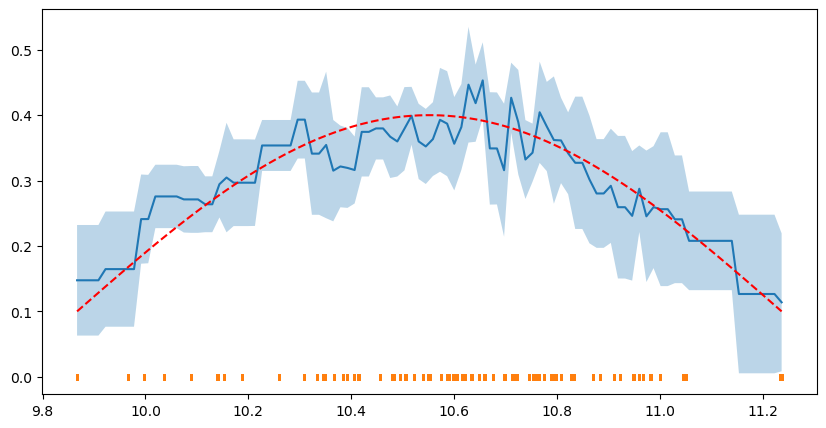

In [35]:
plt.figure(figsize=(10,5))

plt.plot(X_test.flatten(),cate)
plt.fill_between(X_test.flatten(),cate_lower,cate_upper,label="95% CI",alpha=0.3)
plt.plot(X.ravel(),np.zeros_like(X.ravel()), '|',markersize=5)
plt.plot(X_test.flatten(),true_cate(X_test).ravel(),'r--',label="True CATE")




In [36]:
ate_hat = est.ate(X=X)

In [40]:
ate_hat

np.float64(0.3384510772906622)

In [39]:
TE_true.mean()

np.float64(0.3399086196973253)

In [42]:
idx_train, idx_test = train_test_split(np.arange(len(Y)),
    test_size=0.2,random_state=319)


Y_train, Y_test = Y[idx_train], Y[idx_test]
T_train, T_test = T[idx_train], T[idx_test]
W_train, W_test = W[idx_train], W[idx_test]
X_train, X_test = X[idx_train], X[idx_test]

(array([4.110e+02, 6.610e+02, 7.510e+02, 6.690e+02, 9.460e+02, 1.593e+03,
        7.780e+02, 5.800e+02, 6.870e+02, 7.910e+02, 6.480e+02, 5.980e+02,
        6.110e+02, 7.210e+02, 9.070e+02, 8.470e+02, 7.140e+02, 5.500e+02,
        5.220e+02, 6.020e+02, 1.029e+03, 1.248e+03, 1.562e+03, 1.105e+03,
        6.900e+02, 4.350e+02, 3.690e+02, 3.390e+02, 2.730e+02, 2.580e+02,
        2.320e+02, 1.770e+02, 1.120e+02, 9.000e+01, 6.200e+01, 1.010e+02,
        9.200e+01, 1.010e+02, 1.170e+02, 6.700e+01, 4.200e+01, 3.400e+01,
        1.700e+01, 8.000e+00, 4.000e+00, 3.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00]),
 array([0.02894165, 0.04242753, 0.05591342, 0.0693993 , 0.08288519,
        0.09637107, 0.10985696, 0.12334284, 0.13682873, 0.15031462,
        0.1638005 , 0.17728639, 0.19077227, 0.20425816, 0.21774404,
        0.23122993, 0.24471581, 0.2582017 , 0.27168758, 0.28517347,
        0.29865935, 0.31214524, 0.32563112, 0.33911701, 0.35260289,
        0.36608878, 0.37957466, 0.39

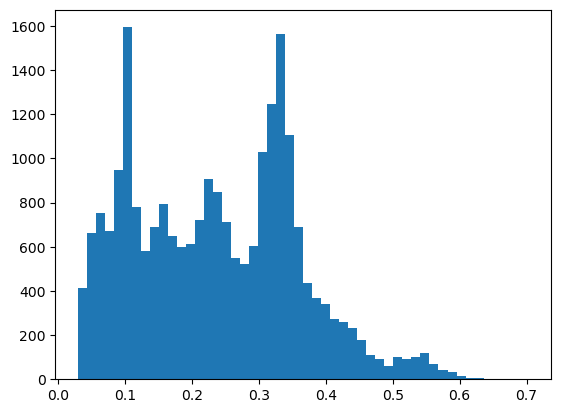

In [44]:
propensity_hat = cross_val_predict(LogisticRegressionCV(cv=3),W_train,T_train,cv=3,
    method = 'predict_proba')[:,1]


plt.hist(propensity_hat,bins=50)

In [46]:
est = CausalForestDML(
    model_y = LassoCV(cv=3),
    model_t = LogisticRegressionCV(cv=3),
    n_estimators = 8000,
    min_samples_leaf = 10,
    max_depth = 40,
    max_samples = 0.05,
    discrete_treatment = True,
    random_state = 123
)


est.fit(Y_train,T_train,X=X_train,W=W_train)

/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LogisticRegressionCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")
/home/georgehagstrom/miniforge3/envs/DATA622/lib/python3.11/site-packages/econml/sklearn_extensions/model_selection.py:550: UserWarning: Model LassoCV(cv=3) has a non-default cv attribute, which will be ignored
  warnings.warn(f"Model {sub_model} has a non-default cv attribute, which will be ignored")


In [47]:
X_grid = np.linspace(income_min,income_max,100).reshape(-1,1)

cate = est.effect(X_grid)


cate_lower, cate_upper = est.effect_interval(X_grid)

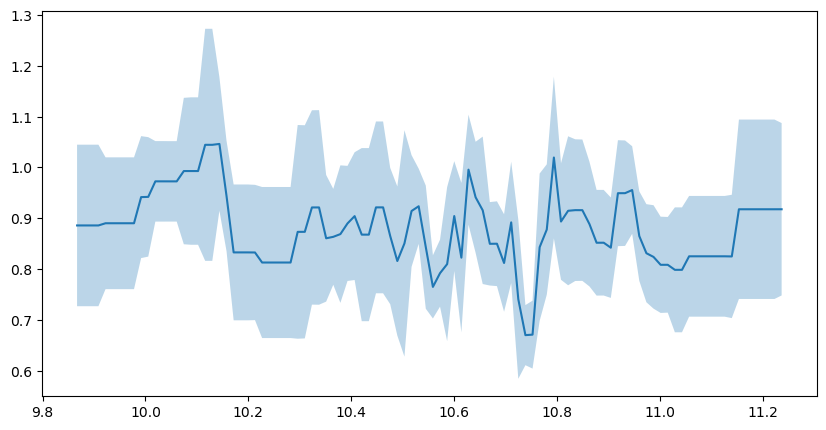

In [49]:




plt.figure(figsize=(10,5))

plt.plot(X_grid.flatten(),cate)
plt.fill_between(X_grid.flatten(),cate_lower,cate_upper,label="95% CI",alpha=0.3)




In [50]:
ate_hat = est.ate(X=X_test)

In [52]:
np.exp(ate_hat)

np.float64(2.3849464276194685)

In [53]:
rscore = est.score(Y_test,T_test,X=X_test,W=W_test)
rscore

0.49692815643429716

In [54]:
sens_lb, sens_ub = est.sensitivity_interval(alpha=0.05,c_t=0.1,c_y=0.3)

In [56]:
sens_ub

np.float64(1.2142399317752104)